Este Bloque, itera los distintos time series y los pasa a un csv

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

print("Google Drive montado en '/content/drive'")

import pandas as pd
import re
import os
import numpy as np
import random
import math
import matplotlib.pyplot as plt
import time
import itertools

# Loop through TS1, TS2, TS3
for i in range(1, 5): # Iterates for 1, 2, 3 , 4
    input_file_name = f'TS{i}'
    output_file_name = f'TS{i}_processed.csv'

    input_file_path = "/content/drive/MyDrive/Estudios y Más/Apuntes 4ºUNI/MtH/P1/" + input_file_name
    output_csv_path = "/content/data/" + output_file_name

    print(f"\n--- Procesando el archivo: {input_file_path} ---")

    # --- 1. Read the raw data string from the file ---
    raw_data_string = ""
    try:
        with open(input_file_path, 'r') as file:
            raw_data_string = file.read()
        print(f"Archivo '{input_file_path}' leído exitosamente como texto.\n")
    except FileNotFoundError:
        print(f"Error: El archivo no se encontró en la ruta especificada: {input_file_path}")
        print("Por favor, verifica que la ruta sea correcta y que el archivo exista en tu Google Drive.")
        raw_data_string = "" # Ensure it's empty to prevent further errors
    except Exception as e:
        print(f"Ocurrió un error al leer el archivo: {e}")
        raw_data_string = "" # Ensure it's empty

    if not raw_data_string:
        print("No hay datos para procesar debido a un error de lectura.")
    else:
        print(f"\nDatos de entrada sin formato (primeros 200 chars):\n{raw_data_string[:200]}\n")

        # --- 2. Preprocess the string to extract values ---
        # Eliminar corchetes y dividir por espacios
        cleaned_string = raw_data_string.strip('[]')
        values_str = cleaned_string.split()

        # Convert values to numbers (float)
        try:
            values = [float(v) for v in values_str]
            print(f"Valores extraídos: {values[:10]}... (Total: {len(values)} valores)\n")
        except ValueError:
            print("Error: No se pudieron convertir todos los valores a números. Asegúrate de que los valores sean numéricos.")
            values = [] # Vaciar si hay un error para evitar problemas posteriores

        # --- 3. Create DataFrame with only the 'value' column ---
        if values:
            # The default pandas index is sequential (0, 1, 2...) and is not saved to CSV with index=False.
            df_processed = pd.DataFrame({
                'value': values
            })

            print("DataFrame procesado (primeras 5 filas):")
            display(df_processed.head())

            # --- 4. Assign to a CSV file ---
            # Ensure the output directory exists
            output_dir = os.path.dirname(output_csv_path)
            if not os.path.exists(output_dir):
                os.makedirs(output_dir, exist_ok=True)
                print(f"Directorio creado: {output_dir}")

            df_processed.to_csv(output_csv_path, index=False)
            print(f"\nDatos guardados en '{output_csv_path}'")
        else:
            print("No se procesaron datos debido a un error en los valores de entrada.")

Mounted at /content/drive
Google Drive montado en '/content/drive'

--- Procesando el archivo: /content/drive/MyDrive/Estudios y Más/Apuntes 4ºUNI/MtH/P1/TS1 ---
Archivo '/content/drive/MyDrive/Estudios y Más/Apuntes 4ºUNI/MtH/P1/TS1' leído exitosamente como texto.


Datos de entrada sin formato (primeros 200 chars):
[ 0.00000000e+00  6.26666168e-01  1.24344944e+00  1.84062276e+00
  2.40876837e+00  2.93892626e+00  3.42273553e+00  3.85256621e+00
  4.22163963e+00  4.52413526e+00  4.75528258e+00  4.91143625e+00
  4.9

Valores extraídos: [0.0, 0.626666168, 1.24344944, 1.84062276, 2.40876837, 2.93892626, 3.42273553, 3.85256621, 4.22163963, 4.52413526]... (Total: 200 valores)

DataFrame procesado (primeras 5 filas):


,value
0,0.000000
1,0.626666
2,1.243449
3,1.840623
4,2.408768


Directorio creado: /content/data

Datos guardados en '/content/data/TS1_processed.csv'

--- Procesando el archivo: /content/drive/MyDrive/Estudios y Más/Apuntes 4ºUNI/MtH/P1/TS2 ---
Archivo '/content/drive/MyDrive/Estudios y Más/Apuntes 4ºUNI/MtH/P1/TS2' leído exitosamente como texto.


Datos de entrada sin formato (primeros 200 chars):
[ 1.23578541  1.41233969  1.55491469  1.79649941  2.00805633  2.23357904
  2.35131745  2.42875279  2.60527955  2.98692237  3.0625529   3.28863731
  3.44314485  3.51348989  3.49984267  3.75748549  3.98

Valores extraídos: [1.23578541, 1.41233969, 1.55491469, 1.79649941, 2.00805633, 2.23357904, 2.35131745, 2.42875279, 2.60527955, 2.98692237]... (Total: 500 valores)

DataFrame procesado (primeras 5 filas):


,value
0,1.235785
1,1.412340
2,1.554915
3,1.796499
4,2.008056



Datos guardados en '/content/data/TS2_processed.csv'

--- Procesando el archivo: /content/drive/MyDrive/Estudios y Más/Apuntes 4ºUNI/MtH/P1/TS3 ---
Archivo '/content/drive/MyDrive/Estudios y Más/Apuntes 4ºUNI/MtH/P1/TS3' leído exitosamente como texto.


Datos de entrada sin formato (primeros 200 chars):
[ 1.49671415  0.8637377   1.65169655  2.52904789  0.77387871  0.77591321
  2.5912851   1.78153319  0.5466543   1.56072302  0.55678365  0.55651403
  1.26625259 -0.8869393  -0.69652215  0.468167    0.01

Valores extraídos: [1.49671415, 0.8637377, 1.65169655, 2.52904789, 0.77387871, 0.77591321, 2.5912851, 1.78153319, 0.5466543, 1.56072302]... (Total: 1000 valores)

DataFrame procesado (primeras 5 filas):


,value
0,1.496714
1,0.863738
2,1.651697
3,2.529048
4,0.773879



Datos guardados en '/content/data/TS3_processed.csv'

--- Procesando el archivo: /content/drive/MyDrive/Estudios y Más/Apuntes 4ºUNI/MtH/P1/TS4 ---
Archivo '/content/drive/MyDrive/Estudios y Más/Apuntes 4ºUNI/MtH/P1/TS4' leído exitosamente como texto.


Datos de entrada sin formato (primeros 200 chars):
[ 2.09931796e+00  1.26054153e+00  4.21612088e-01  6.10144690e+00
  1.28401231e+00 -9.16420759e-01  1.40234625e+00  8.59446003e-01
  2.14306293e+00 -1.18030408e+00  2.17303825e+00  1.30810380e+00
  1.9

Valores extraídos: [2.09931796, 1.26054153, 0.421612088, 6.1014469, 1.28401231, -0.916420759, 1.40234625, 0.859446003, 2.14306293, -1.18030408]... (Total: 1000 valores)

DataFrame procesado (primeras 5 filas):


,value
0,2.099318
1,1.260542
2,0.421612
3,6.101447
4,1.284012



Datos guardados en '/content/data/TS4_processed.csv'


In [ ]:
class Solution:
    def __init__(self, split_points):
        """
        Initializes a Solution object representing a specific set of segment boundaries.
        :param split_points: Array of indices where the time series is divided.
        """
        # Ensure split points are always sorted to define chronological segments
        self.split_points = np.sort(split_points)
        # Initialize cost (Avg MSE) as infinity until evaluated
        self.cost = float('inf')
        # Track how many objective function calls this specific solution triggered
        self.evaluations = 0

    def __repr__(self):
        return f"Solution(splits={self.split_points.tolist()}, cost={self.cost:.4f}, evals={self.evaluations})"

def calculate_segment_mse(y):
    """
    Calculates the MSE of a linear fit for a segment of values in y.
    (NumPy optimized version)
    """
    n = len(y)
    if n <= 2:
        return 0.0
    x = np.arange(n)
    # Direct calculation of the regression line, significantly faster than np.poly1d
    coeffs = np.polyfit(x, y, 1)
    y_pred = coeffs[0] * x + coeffs[1]
    return np.mean((y - y_pred)**2)

def objective_function(solution, time_series_data, k):
    """
    Evaluates solution quality by extracting values to NumPy
    only once for maximum execution speed.
    """
    splits = [0] + solution.split_points.tolist() + [len(time_series_data)]
    total_mse = 0.0

    # KEY: Extract to numpy array once before the loop
    y_values = time_series_data['value'].values

    for i in range(k):
        start_idx = splits[i]
        end_idx = splits[i+1]

        # Fast slicing over the NumPy array
        segment_y = y_values[start_idx:end_idx]
        total_mse += calculate_segment_mse(segment_y)

    solution.cost = total_mse / k
    return solution.cost

def generate_random_solution(n_points, k):
    """
    Creates a random valid partition of the time series into k segments.
    """
    # Potential split locations are any index between start and end
    possible_splits = np.arange(1, n_points)
    # Select k-1 points to create k segments
    chosen_splits = np.random.choice(possible_splits, size=k-1, replace=False)
    return Solution(chosen_splits)

def random_search(time_series_data, k, iterations=1000):
    """
    Simple metaheuristic: explores the search space by sampling random solutions.
    """
    n_points = len(time_series_data)
    best_solution = None

    for _ in range(iterations):
        # 1. Generate a new random candidate
        current_solution = generate_random_solution(n_points, k)
        # 2. Evaluate its cost
        current_cost = objective_function(current_solution, time_series_data, k)

        # 3. Keep the best solution found so far
        if best_solution is None or current_cost < best_solution.cost:
            best_solution = current_solution

    return best_solution

In [ ]:
def create_neighbor_from_move(current_solution, point_idx, delta, n_points):
    """
    Base Move Operator: Generates a new neighbor by applying a specific delta
    to a specific split point.
    Returns the new Solution if valid, or None if the move breaks constraints.
    """
    splits = current_solution.split_points.copy()
    new_val = splits[point_idx] + delta

    # Constraints: must be within bounds and unique
    if 0 < new_val < n_points and new_val not in splits:
        splits[point_idx] = new_val
        return Solution(splits) # The Solution class automatically sorts them

    return None

def get_neighbors(current_solution, n_points, variability_pct):
    """
    For Hill Climbing: Explores the ENTIRE neighborhood.
    Uses the base move operator to generate all possible valid neighbors.
    """
    neighbors = []
    splits = current_solution.split_points
    max_variation = max(1, int(np.round(n_points * variability_pct)))

    for i in range(len(splits)):
        for delta in range(-max_variation, max_variation + 1):
            if delta == 0:
                continue

            # Use the unified base operator
            new_neighbor = create_neighbor_from_move(current_solution, i, delta, n_points)
            if new_neighbor is not None:
                neighbors.append(new_neighbor)

    return neighbors

def get_random_neighbor(current_solution, n_points, variability_pct):
    """
    For Simulated Annealing: Explores a SINGLE random neighbor.
    Uses the exact same base move operator as Hill Climbing.
    """
    splits = current_solution.split_points
    max_variation = max(1, int(np.round(n_points * variability_pct)))

    # Select a random split point and a random delta
    idx_to_change = random.randint(0, len(splits) - 1)
    delta_options = [d for d in range(-max_variation, max_variation + 1) if d != 0]
    delta = random.choice(delta_options)

    # Use the unified base operator
    new_neighbor = create_neighbor_from_move(current_solution, idx_to_change, delta, n_points)

    # Return the new neighbor if valid, otherwise return the current solution unchanged
    return new_neighbor if new_neighbor is not None else current_solution

In [ ]:
def print_assessment_tables(results_df, tuning_params, algorithm_name):
    """
    Prints the assessment tables formatted as in the user-provided image.
    """
    print("\n" + "="*40)
    print("      TABLA 1: EVALUACIÓN EXPERIMENTAL")
    print("="*40)

    mean_cost = results_df['cost'].mean()
    std_cost = results_df['cost'].std()
    total_evals = results_df['evaluations'].sum()
    n_segments = results_df['n_segments'].iloc[0]

    assessment_data = {
        "N(segments)": [n_segments],
        "Metodo": [algorithm_name],
        "Precision(avg MSE)": [f"{mean_cost:.6f}"],
        "Variabilidad(std MSE)": [f"{std_cost:.6f}"],
        "Coste(Evaluations)": [f"{total_evals:,}"]
    }
    assessment_df = pd.DataFrame(assessment_data)
    print(assessment_df.to_string(index=False))
    print("="*40)

    print("\n" + "="*40)
    print("  TABLA 2: AJUSTE DE HIPERPARÁMETROS")
    print("="*40)

    tuning_data = {
        "Metodo": [algorithm_name],
        "Iterations": [tuning_params.get('iterations', 'N/A')],
        "Runs in Experiment": [tuning_params['num_runs']]
    }
    tuning_df = pd.DataFrame(tuning_data)
    print(tuning_df.to_string(index=False))
    print("="*40)

In [ ]:
def hill_climbing(time_series_data, k, iterations=1000, variability_pct=0.01):
    """
    Steepest Ascent Hill Climbing: iteratively moves to the best neighbor in the local search space.
    """
    n_points = len(time_series_data)

    # 1. Start at a random point in the search space
    current_solution = generate_random_solution(n_points, k)
    current_cost = objective_function(current_solution, time_series_data, k)

    evaluations_count = 1

    # 2. Iteratively explore neighbors
    while evaluations_count < iterations:
        # Generate all possible neighbors by shifting existing splits
        neighbors = get_neighbors(current_solution, n_points, variability_pct)

        best_neighbor = None
        best_neighbor_cost = float('inf')

        # 3. Steepest Ascent: Check every neighbor and find the best one
        for neighbor in neighbors:
            if evaluations_count >= iterations:
                break

            cost = objective_function(neighbor, time_series_data, k)
            evaluations_count += 1

            if cost < best_neighbor_cost:
                best_neighbor = neighbor
                best_neighbor_cost = cost

        # 4. Stopping Criterion: If no neighbor is better than the current solution, we are at a local optimum
        if best_neighbor is None or best_neighbor_cost >= current_solution.cost:
            break

        # 5. Move: Update current position to the best neighbor found
        current_solution = best_neighbor

    current_solution.evaluations = evaluations_count
    return current_solution

In [ ]:
def simulated_annealing(time_series_data, k, iterations=5000, variability_pct=0.01, initial_temp=100.0, alpha=0.95):
    """
    Executes the Simulated Annealing metaheuristic.
    """
    n_points = len(time_series_data)

    # Initialization
    current_solution = generate_random_solution(n_points, k)
    current_cost = objective_function(current_solution, time_series_data, k)

    best_solution = current_solution
    best_cost = current_cost

    temp = initial_temp
    evaluations_count = 1

    for _ in range(iterations):
        neighbor = get_random_neighbor(current_solution, n_points, variability_pct)

        # Skip if no valid neighbor was generated
        if np.array_equal(neighbor.split_points, current_solution.split_points):
            continue

        neighbor_cost = objective_function(neighbor, time_series_data, k)
        evaluations_count += 1

        delta = neighbor_cost - current_cost

        # Metropolis acceptance criterion
        if delta < 0 or random.random() < math.exp(-delta / temp):
            current_solution = neighbor
            current_cost = neighbor_cost

            # Track the absolute best found across all temperatures
            if current_cost < best_cost:
                best_solution = current_solution
                best_cost = current_cost

        # Geometric cooling schedule
        temp *= alpha

        # Early stopping if temperature approaches zero
        if temp < 1e-8:
            break

    best_solution.evaluations = evaluations_count
    best_solution.cost = best_cost # Ensure the returned solution holds the best cost
    return best_solution

In [ ]:
def visualize_solution(best_solution, time_series_data, k, title_prefix="Solution"):
    """
    Plots the time series with the fitted piecewise linear regression lines
    and split points for the given solution.
    """
    plt.figure(figsize=(15, 7))

    # 1. Plot the raw original data points as a background scatter plot
    plt.scatter(time_series_data['time_unit'], time_series_data['value'], color='lightgray', alpha=0.5, label='Data Points', s=10)

    # 2. Reconstruct segment boundaries (0, splits..., N)
    splits = [0] + best_solution.split_points.tolist() + [len(time_series_data)]
    colors = plt.cm.viridis(np.linspace(0, 1, k))

    # 3. Iterate and plot each segment independently
    for i in range(k):
        start_idx = splits[i]
        end_idx = splits[i+1]

        segment_data = time_series_data.iloc[start_idx:end_idx]
        if segment_data.empty: continue

        x = segment_data['time_unit'].values
        y = segment_data['value'].values

        # Plot the segment points with a unique color
        plt.scatter(x, y, color=colors[i], s=15, alpha=0.8)

        # Fit and plot a linear trend line for segments with sufficient data
        if len(x) > 2:
            coefficients = np.polyfit(x, y, 1)
            polynomial = np.poly1d(coefficients)
            x_range = np.linspace(x.min(), x.max(), 100)
            plt.plot(x_range, polynomial(x_range), color=colors[i], linestyle='-', linewidth=3)

        # Draw vertical lines to indicate split boundaries
        if i > 0:
            split_time = time_series_data.iloc[start_idx]['time_unit']
            plt.axvline(x=split_time, color='red', linestyle='--', alpha=0.6)

    plt.title(f"{title_prefix} - {k} Segments - Total Avg MSE: {best_solution.cost:.4f}")
    plt.xlabel("Time Unit")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.show()

In [ ]:
def run_experiment(algorithm_name, algorithm_func, dataset_path, k_segments, tuning_config):
    """
    Executes a comparative experiment: runs a specific algorithm multiple times
    on a given dataset and tracks performance metrics.
    """
    print(f"\n{'='*60}")
    print(f"--- RUNNING: {algorithm_name} on {dataset_path} ---")
    print(f"{'='*60}")

    # 1. Load the target CSV dataset
    try:
        df = pd.read_csv(dataset_path)
    except FileNotFoundError:
        print(f"Error: Dataset not found at {dataset_path}")
        return None, None

    # Ensure time units exist for regression mapping
    if 'time_unit' not in df.columns:
        df['time_unit'] = range(len(df))

    print(f"Data loaded: {len(df)} points. Target segments: {k_segments}")

    run_results = []
    absolute_best_solution = None

    # 2. Experimental Loop: Run the algorithm multiple times for statistical significance
    start_time_total = time.time()

    for run in range(1, tuning_config['num_runs'] + 1):
        print(f"Executing Run {run}/{tuning_config['num_runs']}...", end='\r')

        run_start_time = time.time()

        # Call the specific metaheuristic function
        best_sol_run = algorithm_func(
            df,
            k_segments,
            iterations=tuning_config.get('iterations', 1000)
        )

        run_end_time = time.time()
        run_duration = run_end_time - run_start_time

        # Record metrics for later analysis
        run_results.append({
            'run_id': run,
            'cost': best_sol_run.cost,
            'evaluations': getattr(best_sol_run, 'evaluations', tuning_config.get('iterations', 1000)),
            'n_segments': k_segments,
            'execution_time_sec': run_duration
        })

        # Keep track of the best solution ever found across all runs
        if absolute_best_solution is None or best_sol_run.cost < absolute_best_solution.cost:
            absolute_best_solution = best_sol_run

    end_time_total = time.time()
    print(f"\nExperiment finished in {end_time_total - start_time_total:.2f} seconds.")

    # 3. Aggregation: Summarize results in a DataFrame
    results_df = pd.DataFrame(run_results)
    print(f"Avg MSE: {results_df['cost'].mean():.4f} | Avg Time: {results_df['execution_time_sec'].mean():.4f}s")

    return results_df, absolute_best_solution

In [ ]:
def random_search_multi_run_study(dataset_path: str, k_segments: int, max_iterations: int = 10000, num_runs: int = 10):
    """
    Executes RS multiple times to calculate the average convergence
    and reduce the impact of randomness in the analysis.
    """
    try:
        df = pd.read_csv(dataset_path)
    except FileNotFoundError:
        print(f"Error: File not found -> {dataset_path}")
        return None, None

    n_points = len(df)
    y_values = df.iloc[:, -1].values

    print(f"Running RS study for {dataset_path} (k={k_segments}, {num_runs} runs)...")

    valid_indices = range(1, n_points)
    num_splits = k_segments - 1
    all_runs_history = []

    for run in range(num_runs):
        best_mse = float('inf')
        run_history = []

        for _ in range(max_iterations):
            splits = sorted(random.sample(valid_indices, num_splits))
            current_mse = objective_function(splits, y_values, n_points)

            if current_mse < best_mse:
                best_mse = current_mse

            run_history.append(best_mse)

        all_runs_history.append(run_history)

    all_runs_matrix = np.array(all_runs_history)
    avg_history = np.mean(all_runs_matrix, axis=0)

    return all_runs_matrix, avg_history

def find_optimal_stopping_point(avg_history: np.ndarray, tolerance_pct: float = 0.02) -> int:
    """Finds the optimal stopping iteration based on the average curve."""
    best_overall = avg_history[-1]
    threshold = best_overall * (1 + tolerance_pct)

    for i, mse in enumerate(avg_history):
        if mse <= threshold:
            return i
    return len(avg_history)

def plot_rs_convergence_robust(datasets_info: list, max_iterations: int = 10000, num_runs: int = 10):
    """Generates a 2x2 plot showing individual runs and the average."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for idx, info in enumerate(datasets_info):
        all_runs, avg_history = random_search_multi_run_study(
            info['path'], info['k'], max_iterations, num_runs
        )

        if all_runs is None:
            continue

        ax = axes[idx]

        for run_idx in range(num_runs):
            ax.plot(all_runs[run_idx], color='lightblue', alpha=0.4,
                    linewidth=1, label='Individual Run' if run_idx == 0 else "")

        ax.plot(avg_history, color='darkblue', linewidth=2.5, label='Average Convergence')

        optimal_iter = find_optimal_stopping_point(avg_history, tolerance_pct=0.02)
        ax.axvline(x=optimal_iter, color='red', linestyle='--',
                   label=f'Optimal Average Stop: {optimal_iter} iters')

        ax.set_title(f"Robust RS Convergence - {info['name']} (k={info['k']})", fontsize=12)
        ax.set_xlabel('Iterations', fontsize=10)
        ax.set_ylabel('Mean MSE', fontsize=10)
        ax.grid(True, linestyle='--', alpha=0.7)
        ax.legend()

    plt.tight_layout()
    plt.savefig("RS_Convergence_Robust.png", dpi=300)
    print("\nCompleted! Robust plot saved as 'RS_Convergence_Robust.png'")
    plt.show()

if __name__ == "__main__":
    datasets = [
        {'path': '/content/data/TS1_processed.csv', 'k': 9, 'name': 'TS1'},
        {'path': '/content/data/TS2_processed.csv', 'k': 10, 'name': 'TS2'},
        {'path': '/content/data/TS3_processed.csv', 'k': 20, 'name': 'TS3'},
        {'path': '/content/data/TS4_processed.csv', 'k': 50, 'name': 'TS4'}
    ]

    #plot_rs_convergence_robust(datasets, max_iterations=10000, num_runs=10)

In [ ]:
def hc_restarts_study(dataset_path: str, k_segments: int, max_restarts: int = 15, num_trials: int = 5):
    """
    Analyzes the optimal number of restarts for Hill Climbing.
    Records the cumulative best MSE over sequential restarts and averages over multiple trials.
    """
    try:
        df = pd.read_csv(dataset_path)
    except FileNotFoundError:
        print(f"Error: File not found -> {dataset_path}")
        return None, None

    print(f"Running HC Restarts Study for {dataset_path} (k={k_segments})...")
    all_trials_history = []

    for trial in range(num_trials):
        best_global_mse = float('inf')
        cumulative_history = []

        for restart in range(1, max_restarts + 1):
            current_solution = hill_climbing(df, k_segments, iterations=1000, variability_pct=0.01)
            current_mse = current_solution.cost

            if current_mse < best_global_mse:
                best_global_mse = current_mse

            cumulative_history.append(best_global_mse)

        all_trials_history.append(cumulative_history)

    avg_history = np.mean(all_trials_history, axis=0)
    return all_trials_history, avg_history

def find_optimal_restarts(avg_history: np.ndarray, tolerance_pct: float = 0.01) -> int:
    """Finds the restart number where the MSE is within 1% of the absolute minimum found."""
    best_overall = avg_history[-1]
    threshold = best_overall * (1 + tolerance_pct)

    for i, mse in enumerate(avg_history):
        if mse <= threshold:
            return i + 1  # +1 because index 0 represents 1 execution
    return len(avg_history)

def plot_hc_restarts_robust(datasets_info: list, max_restarts: int = 15, num_trials: int = 5):
    """Plots the convergence of the cumulative best MSE for HC restarts."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for idx, info in enumerate(datasets_info):
        all_trials, avg_history = hc_restarts_study(
            info['path'], info['k'], max_restarts, num_trials
        )

        if all_trials is None:
            continue

        ax = axes[idx]

        for trial_idx in range(num_trials):
            ax.plot(range(1, max_restarts + 1), all_trials[trial_idx],
                    color='lightgreen', alpha=0.4, linewidth=1,
                    label='Individual Trial' if trial_idx == 0 else "")

        ax.plot(range(1, max_restarts + 1), avg_history,
                color='darkgreen', linewidth=2.5, label='Average Best MSE')

        optimal_restart = find_optimal_restarts(avg_history, tolerance_pct=0.01)
        ax.axvline(x=optimal_restart, color='red', linestyle='--',
                   label=f'Optimal Restarts: {optimal_restart}')

        ax.set_title(f"HC Restarts Optimization - {info['name']} (k={info['k']})", fontsize=12)
        ax.set_xlabel('Number of Executions (Restarts)', fontsize=10)
        ax.set_ylabel('Cumulative Best MSE', fontsize=10)
        ax.set_xticks(range(1, max_restarts + 1))
        ax.grid(True, linestyle='--', alpha=0.7)
        ax.legend()

    plt.tight_layout()
    plt.savefig("HC_Restarts_Robust.png", dpi=300)
    print("\nCompleted! Plot saved as 'HC_Restarts_Robust.png'")
    plt.show()

if __name__ == "__main__":
    datasets = [
        {'path': '/content/data/TS1_processed.csv', 'k': 9, 'name': 'TS1'},
        {'path': '/content/data/TS2_processed.csv', 'k': 10, 'name': 'TS2'},
        {'path': '/content/data/TS3_processed.csv', 'k': 20, 'name': 'TS3'},
        {'path': '/content/data/TS4_processed.csv', 'k': 50, 'name': 'TS4'}
    ]

    #plot_hc_restarts_robust(datasets, max_restarts=20, num_trials=10)

In [ ]:
def get_cooling_schedule(cooling_type: str, T: float, alpha: float) -> float:
    if cooling_type == 'geometric':
        return T * alpha
    elif cooling_type == 'linear':
        return T - alpha
    return T * alpha

def sa_fast_grid_search(df: pd.DataFrame, k_segments: int, T0: float, alpha: float, L: int, cooling_type: str) -> float:
    n_points = len(df)
    y_values = df.iloc[:, -1].values

    splits = sorted(random.sample(range(1, n_points), k_segments - 1))
    current_solution = Solution(splits)
    current_mse = objective_function(current_solution, df, k_segments)

    best_mse = current_mse
    T = T0
    min_T = 1e-3
    max_var = max(1, int(np.round(n_points * 0.01)))

    while T > min_T:
        for _ in range(L):
            idx = random.randint(0, len(splits) - 1)
            delta_opts = [d for d in range(-max_var, max_var + 1) if d != 0]
            delta = random.choice(delta_opts)

            new_splits = current_solution.split_points.copy()
            new_val = new_splits[idx] + delta

            if 0 < new_val < n_points and new_val not in new_splits:
                new_splits[idx] = new_val
                new_splits = sorted(new_splits)
                new_neighbor = Solution(new_splits)
                new_mse = objective_function(new_neighbor, df, k_segments)

                delta_E = new_mse - current_mse
                if delta_E < 0 or random.random() < math.exp(-delta_E / T):
                    current_solution = new_neighbor
                    current_mse = new_mse
                    if current_mse < best_mse:
                        best_mse = current_mse

        T = get_cooling_schedule(cooling_type, T, alpha)
        if cooling_type == 'linear' and T <= 0:
            break

    return best_mse

def run_deep_grid_search(datasets_info: list):
    """Executes a deeper Grid Search prioritizing slower cooling and more epochs."""

    # Updated Grid: Slower cooling rates and more epochs for complex spaces
    temperatures = [50, 100]
    alphas_geom = [0.95, 0.98, 0.99]
    alphas_linear = [0.5, 1.0]
    L_values = [50, 100]
    cooling_types = ['geometric', 'linear']

    for info in datasets_info:
        dataset_path = info['path']
        k_segments = info['k']

        try:
            df = pd.read_csv(dataset_path)
        except FileNotFoundError:
            print(f"Error: File not found -> {dataset_path}")
            continue

        print(f"\n--- Deep Grid Search for {info['name']} (k={k_segments}) ---")
        best_combo = None
        best_global_mse = float('inf')

        for c_type in cooling_types:
            alphas = alphas_geom if c_type == 'geometric' else alphas_linear

            for T0, alpha, L in itertools.product(temperatures, alphas, L_values):
                # We run 2 trials per combination to avoid lucky/unlucky runs
                mses = []
                for _ in range(2):
                    mse = sa_fast_grid_search(df, k_segments, T0, alpha, L, c_type)
                    mses.append(mse)
                avg_mse = np.mean(mses)

                print(f"Tested: {c_type}, T0={T0}, alpha={alpha}, L={L} -> Avg MSE: {avg_mse:.4f}")

                if avg_mse < best_global_mse:
                    best_global_mse = avg_mse
                    best_combo = {
                        'Cooling': c_type, 'T0': T0, 'Alpha': alpha, 'L': L, 'MSE': round(avg_mse, 4)
                    }

        print(f">>> BEST for {info['name']}: {best_combo}")

if __name__ == "__main__":
    datasets = [
        {'path': '/content/data/TS1_processed.csv', 'k': 9, 'name': 'TS1'},
        {'path': '/content/data/TS2_processed.csv', 'k': 10, 'name': 'TS2'},
        {'path': '/content/data/TS3_processed.csv', 'k': 20, 'name': 'TS3'},
        {'path': '/content/data/TS4_processed.csv', 'k': 50, 'name': 'TS4'}
    ]

    run_deep_grid_search(datasets)


--- Deep Grid Search for TS1 (k=9) ---
Tested: geometric, T0=50, alpha=0.95, L=50 -> Avg MSE: 1.1164



KeyboardInterrupt



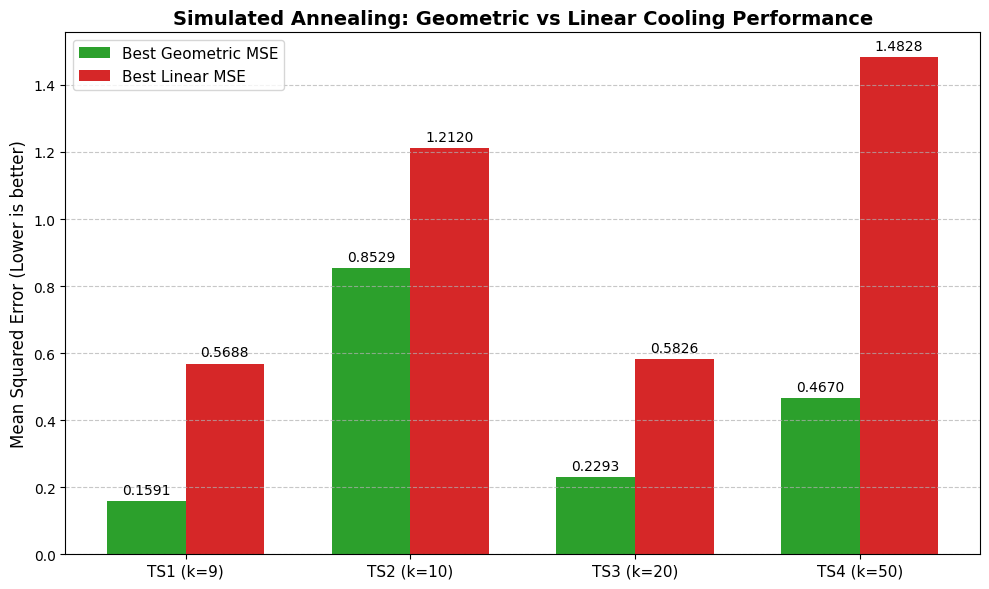

In [ ]:
def plot_sa_grid_search_results():
    """
    Generates a grouped bar chart comparing the best Mean Squared Error (MSE)
    achieved by Geometric vs Linear cooling schedules across all datasets.
    """
    os.makedirs('img', exist_ok=True)

    # Data extracted from the Deep Grid Search results
    datasets = ['TS1 (k=9)', 'TS2 (k=10)', 'TS3 (k=20)', 'TS4 (k=50)']
    best_geometric_mse = [0.1591, 0.8529, 0.2293, 0.4670]
    best_linear_mse = [0.5688, 1.2120, 0.5826, 1.4828]

    x = np.arange(len(datasets))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))

    # Create bars
    rects1 = ax.bar(x - width/2, best_geometric_mse, width, label='Best Geometric MSE', color='#2ca02c')
    rects2 = ax.bar(x + width/2, best_linear_mse, width, label='Best Linear MSE', color='#d62728')

    # Formatting and aesthetics
    ax.set_ylabel('Mean Squared Error (Lower is better)', fontsize=12)
    ax.set_title('Simulated Annealing: Geometric vs Linear Cooling Performance', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(datasets, fontsize=11)
    ax.legend(fontsize=11)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    # Add data labels on top of the bars
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.4f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=10)

    autolabel(rects1)
    autolabel(rects2)

    plt.tight_layout()
    plt.savefig('img/SA_Cooling_Comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

# Execute the plot generation
plot_sa_grid_search_results()


Searching for the Ultimate Best in TS1...


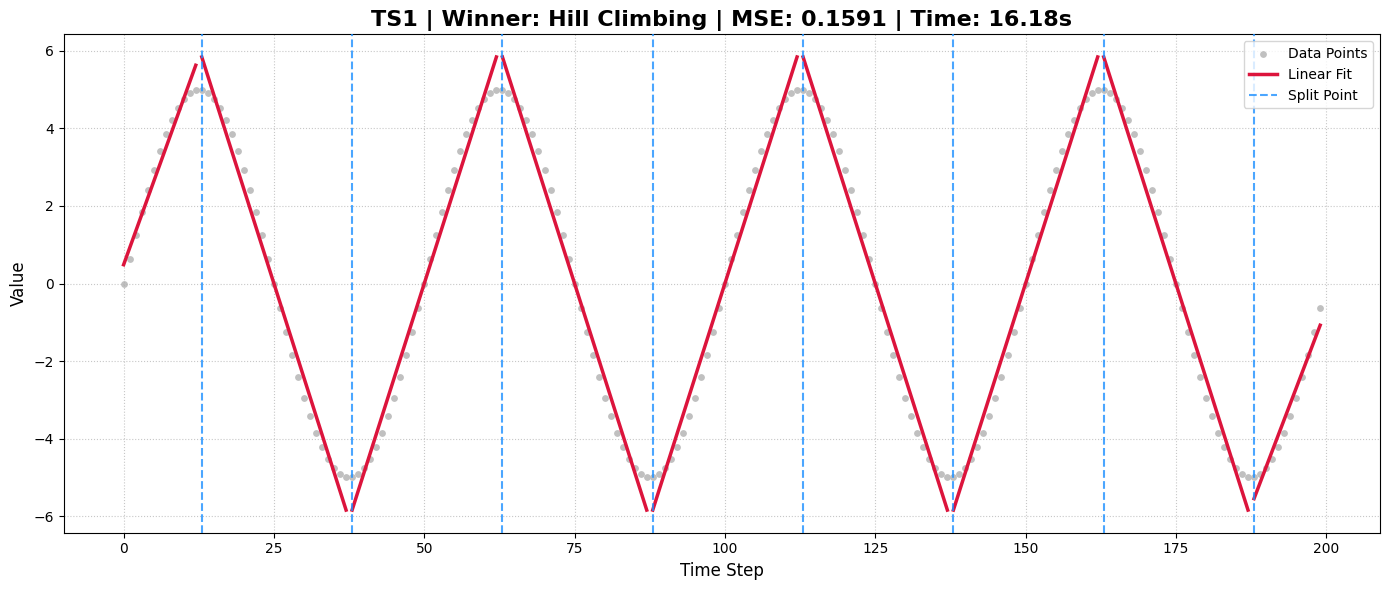


Searching for the Ultimate Best in TS2...


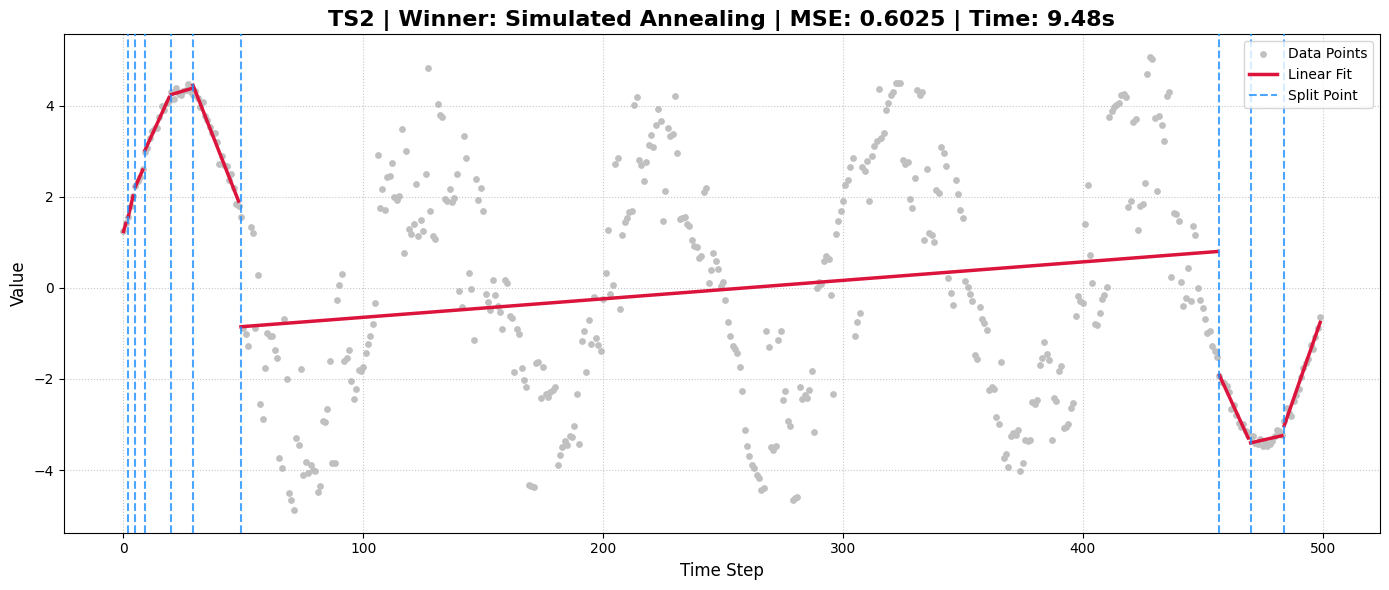


Searching for the Ultimate Best in TS3...


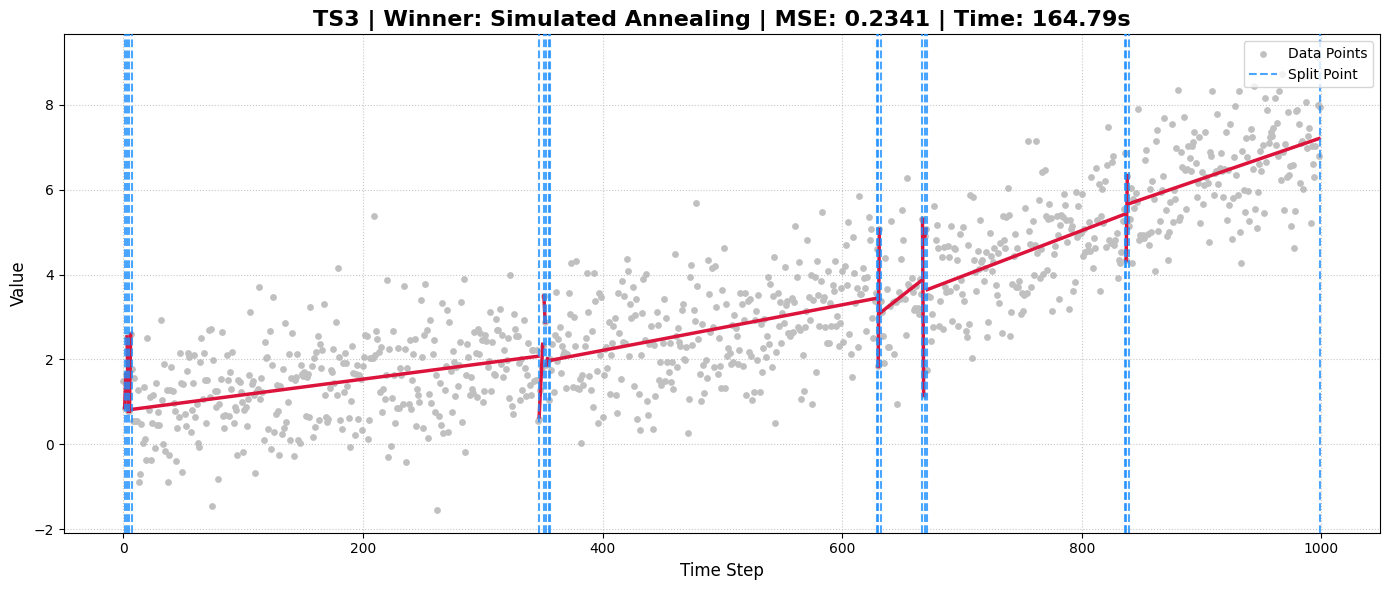


Searching for the Ultimate Best in TS4...


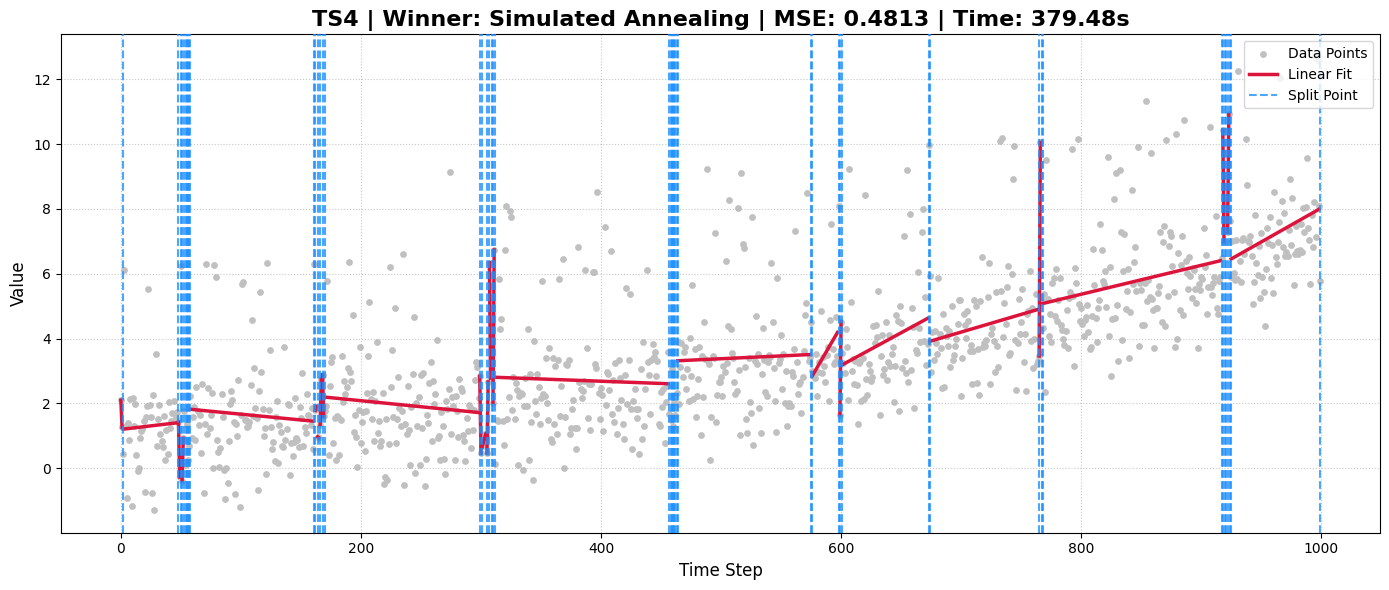

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import math
import time
import os

def plot_ultimate_solution(df, best_splits, k, title, mse, algo_name, exec_time):
    """
    Plots the absolute best segmentation found for a dataset.
    """
    y_values = df.iloc[:, -1].values
    n_points = len(y_values)

    # Safely reconstruct the splits
    splits = [0] + sorted(list(best_splits)) + [n_points]

    plt.figure(figsize=(14, 6))

    # Scatter points for original data
    plt.scatter(range(n_points), y_values, color='silver', s=15, label='Data Points', zorder=1)

    for i in range(k):
        start_idx = splits[i]
        end_idx = splits[i+1]
        segment_y = y_values[start_idx:end_idx]
        x_segment = np.arange(start_idx, end_idx)

        if len(segment_y) > 1:
            coeffs = np.polyfit(np.arange(len(segment_y)), segment_y, 1)
            y_pred = coeffs[0] * np.arange(len(segment_y)) + coeffs[1]
            plt.plot(x_segment, y_pred, color='crimson', linewidth=2.5, zorder=2,
                     label='Linear Fit' if i == 0 else "")

        if start_idx > 0:
            plt.axvline(x=start_idx, color='dodgerblue', linestyle='--', alpha=0.8, zorder=3,
                        label='Split Point' if i == 1 else "")

    plt.title(f"{title} | Winner: {algo_name} | MSE: {mse:.4f} | Time: {exec_time:.2f}s", fontsize=16, fontweight='bold')
    plt.xlabel('Time Step', fontsize=12)
    plt.ylabel('Value', fontsize=12)
    plt.legend(loc='upper right')
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()

    os.makedirs('img', exist_ok=True)
    plt.savefig(f"img/ULTIMATE_{title[:3]}.png", dpi=300, bbox_inches='tight')
    plt.show()

def find_and_plot_ultimate_best(num_runs=3):
    """
    Runs the optimal configurations, compares RS, HC, and SA,
    and plots ONLY the absolute best solution for each dataset, including execution time.
    """
    # Configurations updated with the exact best parameters from previous fine-tuning
    configs = {
        'TS1': {'path': '/content/data/TS1_processed.csv', 'k': 9,  'rs_iters': 7000, 'hc_restarts': 18, 'sa_T0': 100, 'sa_alpha': 0.98, 'sa_L': 100},
        'TS2': {'path': '/content/data/TS2_processed.csv', 'k': 10, 'rs_iters': 9250, 'hc_restarts': 13, 'sa_T0': 50,  'sa_alpha': 0.98, 'sa_L': 100},
        'TS3': {'path': '/content/data/TS3_processed.csv', 'k': 20, 'rs_iters': 4500, 'hc_restarts': 9,  'sa_T0': 50,  'sa_alpha': 0.99, 'sa_L': 100},
        'TS4': {'path': '/content/data/TS4_processed.csv', 'k': 50, 'rs_iters': 3600, 'hc_restarts': 18, 'sa_T0': 100, 'sa_alpha': 0.99, 'sa_L': 100}
    }

    for name, conf in configs.items():
        print(f"\nSearching for the Ultimate Best in {name}...")
        try:
            df = pd.read_csv(conf['path'])
        except FileNotFoundError:
            print(f"File {conf['path']} not found. Skipping.")
            continue

        n_points = len(df)
        valid_indices = range(1, n_points)
        num_splits = conf['k'] - 1

        global_best_mse = float('inf')
        global_best_splits = []
        global_best_algo = ""
        global_best_time = 0.0

        for run in range(num_runs):
            # --- 1. Random Search ---
            start_rs = time.time()
            for _ in range(conf['rs_iters']):
                splits = sorted(random.sample(valid_indices, num_splits))
                sol = Solution(splits)
                mse = objective_function(sol, df, conf['k'])
                if mse < global_best_mse:
                    global_best_mse = mse
                    global_best_splits = list(sol.split_points) # HARD COPY
                    global_best_algo = "Random Search"
            time_rs = time.time() - start_rs
            if global_best_algo == "Random Search" and run == 0:
                global_best_time = time_rs

            # --- 2. Hill Climbing ---
            start_hc = time.time()
            for _ in range(conf['hc_restarts']):
                # HC iterations set to a high safe limit for natural convergence
                sol = hill_climbing(df, conf['k'], iterations=10000, variability_pct=0.01)
                if sol.cost < global_best_mse:
                    global_best_mse = sol.cost
                    global_best_splits = list(sol.split_points) # HARD COPY
                    global_best_algo = "Hill Climbing"
            time_hc = time.time() - start_hc
            if global_best_algo == "Hill Climbing" and run == 0:
                global_best_time = time_hc

            # --- 3. Simulated Annealing ---
            start_sa = time.time()
            splits = sorted(random.sample(valid_indices, num_splits))
            current_sol = Solution(splits)
            current_mse = objective_function(current_sol, df, conf['k'])

            T = conf['sa_T0']
            max_var = max(1, int(np.round(n_points * 0.01)))

            while T > 1e-3:
                for _ in range(conf['sa_L']):
                    idx = random.randint(0, len(splits) - 1)
                    delta = random.choice([d for d in range(-max_var, max_var + 1) if d != 0])
                    new_splits = current_sol.split_points.copy()
                    new_val = new_splits[idx] + delta

                    if 0 < new_val < n_points and new_val not in new_splits:
                        new_splits[idx] = new_val
                        new_splits = sorted(new_splits)
                        new_neighbor = Solution(new_splits)
                        new_mse = objective_function(new_neighbor, df, conf['k'])

                        delta_E = new_mse - current_mse
                        if delta_E < 0 or random.random() < math.exp(-delta_E / T):
                            current_sol = new_neighbor
                            current_mse = new_mse
                            if current_mse < global_best_mse:
                                global_best_mse = current_mse
                                global_best_splits = list(current_sol.split_points) # HARD COPY
                                global_best_algo = "Simulated Annealing"
                T *= conf['sa_alpha']
            time_sa = time.time() - start_sa
            if global_best_algo == "Simulated Annealing" and run == 0:
                global_best_time = time_sa

        plot_ultimate_solution(df, global_best_splits, conf['k'], name, global_best_mse, global_best_algo, global_best_time)

# Execute the final comparison
find_and_plot_ultimate_best(num_runs=3)


--- RUNNING: Random Search on /content/data/TS1_processed.csv ---
Data loaded: 200 points. Target segments: 9

Experiment finished in 118.22 seconds.

      TABLA 1: EVALUACIÓN EXPERIMENTAL
 N(segments)        Metodo Precision(avg MSE) Variabilidad(std MSE) Coste(Evaluations)
           9 Random Search           0.664898              0.074873             50,000

  TABLA 2: AJUSTE DE HIPERPARÁMETROS
       Metodo  Iterations  Runs in Experiment
Random Search        5000                  10

Visualizing the absolute best solution found for Random Search:


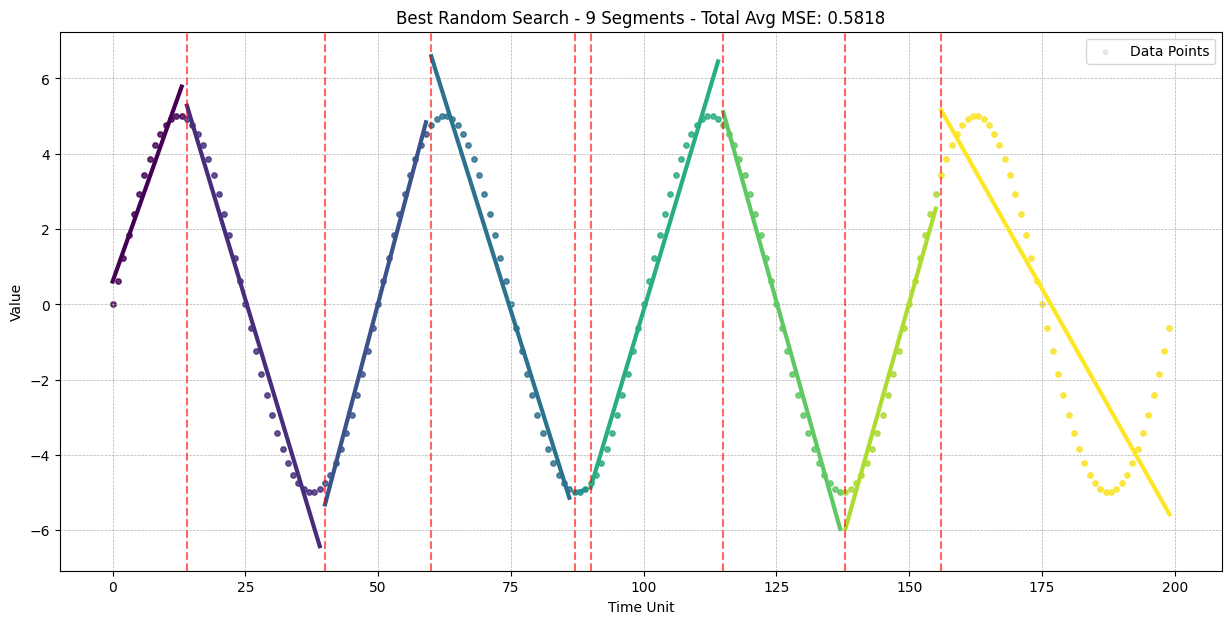

In [ ]:
# Example call for

tuning_rs = {
    'iterations': 5000,
    'num_runs': 10
}

results_ts1, best_ts1 = run_experiment(
    algorithm_name="Random Search",
    algorithm_func=random_search,
    dataset_path="/content/data/TS1_processed.csv",
    k_segments=9,
    tuning_config=tuning_rs
)


--- RUNNING: Hill Climbing (Steepest Ascent) on /content/data/TS1_processed.csv ---
Data loaded: 200 points. Target segments: 9

Experiment finished in 28.19 seconds.

      TABLA 1: EVALUACIÓN EXPERIMENTAL
 N(segments)                          Metodo Precision(avg MSE) Variabilidad(std MSE) Coste(Evaluations)
           9 Hill Climbing (Steepest Ascent)           1.005603              0.470928             11,744

  TABLA 2: AJUSTE DE HIPERPARÁMETROS
                         Metodo  Iterations  Runs in Experiment
Hill Climbing (Steepest Ascent)        5000                  10

Visualizing the absolute best solution found for Hill Climbing (Steepest Ascent):


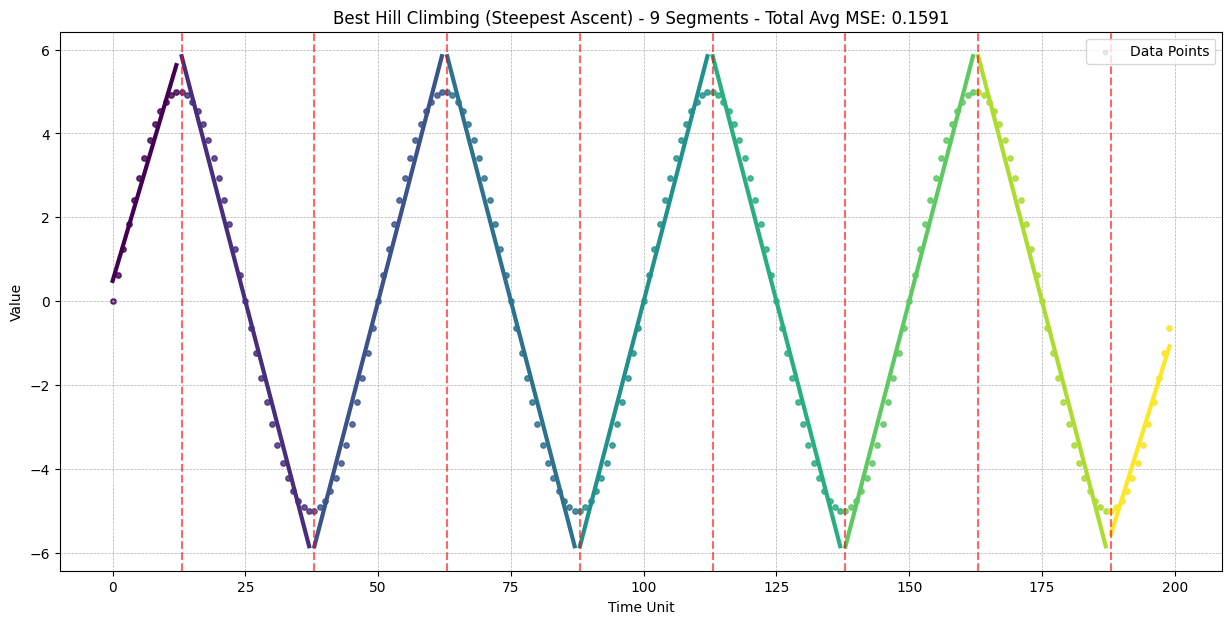

In [ ]:
tuning_hc = {
    'iterations': 5000,    # Max allowed evaluations
    'num_runs': 10,
    'variability_pct': 0.01 # 1% variability for the search space
}

results_hc_ts1, best_hc_ts1 = run_experiment(
    algorithm_name="Hill Climbing (Steepest Ascent)",
    algorithm_func=lambda df, k, iterations: hill_climbing(df, k, iterations, tuning_hc['variability_pct']),
    dataset_path="/content/data/TS1_processed.csv",
    k_segments=9,
    tuning_config=tuning_hc
)


--- RUNNING: Simulated Annealing on /content/data/TS1_processed.csv ---
Data loaded: 200 points. Target segments: 9
Executing Run 10/10...
Experiment finished in 1.79 seconds.

      TABLA 1: EVALUACIÓN EXPERIMENTAL
 N(segments)              Metodo Precision(avg MSE) Variabilidad(std MSE) Coste(Evaluations)
           9 Simulated Annealing           1.458606              0.396289                790

  TABLA 2: AJUSTE DE HIPERPARÁMETROS
             Metodo  Iterations  Runs in Experiment
Simulated Annealing        5000                  10

Visualizing the absolute best solution found for Simulated Annealing:


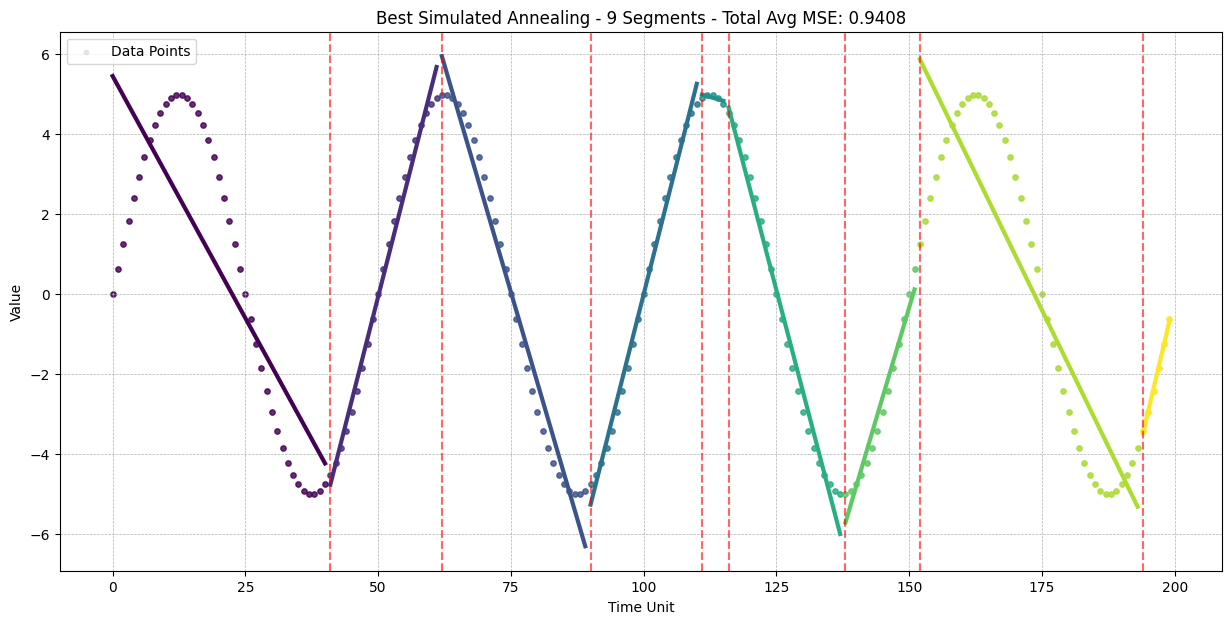

In [ ]:
tuning_sa = {
    'iterations': 5000,
    'num_runs': 10,
    'variability_pct': 0.01,
    'initial_temp': 50.0,
    'alpha': 0.75
}

results_sa_ts1, best_sa_ts1 = run_experiment(
    algorithm_name="Simulated Annealing",
    algorithm_func=lambda df, k, iterations: simulated_annealing(
        df, k, iterations,
        tuning_sa['variability_pct'],
        tuning_sa['initial_temp'],
        tuning_sa['alpha']
    ),
    dataset_path="/content/data/TS1_processed.csv",
    k_segments=9,
    tuning_config=tuning_sa
)

Running Constrained SA on TS2...


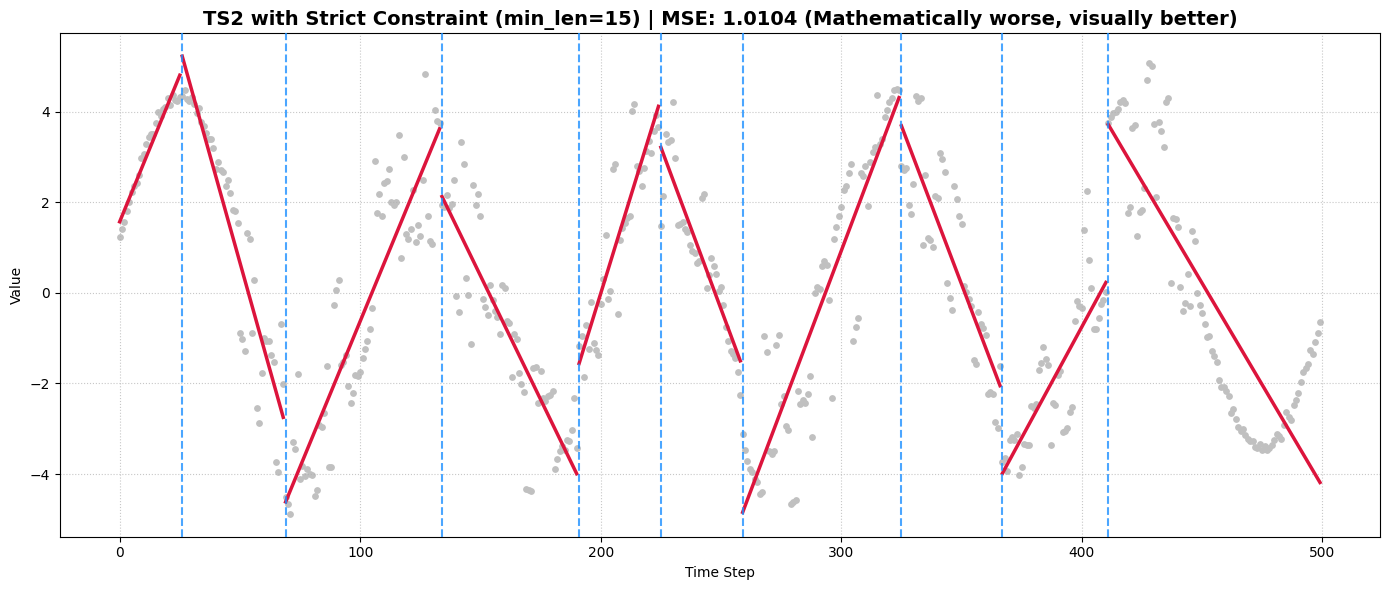

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import math
import time
import os

def plot_constrained_ts2(df, best_splits, k, mse):
    """
    Plots the constrained solution for TS2 to visually prove
    that a 'worse' MSE can represent a better real-world fit.
    """
    y_values = df.iloc[:, -1].values
    n_points = len(y_values)
    splits = [0] + sorted(list(best_splits)) + [n_points]

    plt.figure(figsize=(14, 6))
    plt.scatter(range(n_points), y_values, color='silver', s=15, label='Data Points', zorder=1)

    for i in range(k):
        start_idx = splits[i]
        end_idx = splits[i+1]
        segment_y = y_values[start_idx:end_idx]
        x_segment = np.arange(start_idx, end_idx)

        if len(segment_y) > 1:
            coeffs = np.polyfit(np.arange(len(segment_y)), segment_y, 1)
            y_pred = coeffs[0] * np.arange(len(segment_y)) + coeffs[1]
            plt.plot(x_segment, y_pred, color='crimson', linewidth=2.5, zorder=2)

        if start_idx > 0:
            plt.axvline(x=start_idx, color='dodgerblue', linestyle='--', alpha=0.8, zorder=3)

    plt.title(f"TS2 with Strict Constraint (min_len=15) | MSE: {mse:.4f} (Mathematically worse, visually better)", fontsize=14, fontweight='bold')
    plt.xlabel('Time Step')
    plt.ylabel('Value')
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.show()

def run_ts2_constrained_sa():
    """
    Runs Simulated Annealing on TS2 with a hard minimum segment length constraint.
    """
    path = '/content/data/TS2_processed.csv'
    k = 10
    T0 = 50
    alpha = 0.98
    L = 100
    min_len = 15 # Strict constraint to force following the curve

    try:
        df = pd.read_csv(path)
    except FileNotFoundError:
        print(f"File {path} not found. Check path.")
        return

    n_points = len(df)
    num_splits = k - 1

    def is_valid_split(splits):
        full_splits = [0] + splits + [n_points]
        for i in range(len(full_splits) - 1):
            if full_splits[i+1] - full_splits[i] < min_len:
                return False
        return True

    # Initialize valid random splits
    while True:
        splits = sorted(random.sample(range(min_len, n_points - min_len), num_splits))
        if is_valid_split(splits):
            break

    current_sol = Solution(splits)
    current_mse = objective_function(current_sol, df, k)

    best_mse = current_mse
    best_splits = list(current_sol.split_points)

    T = T0
    max_var = max(1, int(np.round(n_points * 0.01)))

    print("Running Constrained SA on TS2...")
    while T > 1e-3:
        for _ in range(L):
            idx = random.randint(0, len(splits) - 1)
            delta = random.choice([d for d in range(-max_var, max_var + 1) if d != 0])
            new_splits = current_sol.split_points.copy()
            new_val = new_splits[idx] + delta

            if 0 < new_val < n_points and new_val not in new_splits:
                new_splits[idx] = new_val
                new_splits.sort()

                if is_valid_split(new_splits):
                    new_neighbor = Solution(new_splits)
                    new_mse = objective_function(new_neighbor, df, k)

                    delta_E = new_mse - current_mse
                    if delta_E < 0 or random.random() < math.exp(-delta_E / T):
                        current_sol = new_neighbor
                        current_mse = new_mse
                        if current_mse < best_mse:
                            best_mse = current_mse
                            best_splits = list(current_sol.split_points)
        T *= alpha

    plot_constrained_ts2(df, best_splits, k, best_mse)

# Execute
run_ts2_constrained_sa()